This notebook applies Support Vector Machine (SVM) classification to the Iris dataset. The Iris dataset is a well-known multiclass classification benchmark containing measurements of sepal and petal dimensions for three iris species.

## Practical Work (TD #2): Support Vector Machines on the Penguins Dataset

This notebook applies Support Vector Machine (SVM) classification to the Iris dataset. The Iris dataset is a well-known multiclass classification benchmark containing measurements of sepal and petal dimensions for three iris species.

**Dataset:** Seaborn Penguins dataset containing physical measurements of Adelie, Chinstrap, and Gentoo iris flowers.  

**Models:** Support Vector Machine (SVM)

**Goal:** To classify iris flower species using SVM, analyze feature separability, apply preprocessing and visualization, evaluate performance, and understand the impact of kernel choice and hyperparameter tuning.


1. Apply Support Vector Machines (SVM) to classify iris flower species based on body measurements.
2. Explore: 
    - preprocessing
    - visualization
    - model training
    - evaluation 
    - hyperparameter tuning.

This notebook applies Support Vector Machine (SVM) classification to the Iris dataset. The Iris dataset is a well-known multiclass classification benchmark containing measurements of sepal and petal dimensions for three iris species.

### Dataset
* We’ll use Seaborn’s iris flowers dataset, which contains data about three iris flower species:
    - Adelie
    - Chinstrap
    - Gentoo
* Each sample includes physical characteristics like bill length, flipper length, and body mass.

In [1]:
# Data manipulation and numerical operations
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Dataset splitting and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning model
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report




This notebook applies Support Vector Machine (SVM) classification to the Iris dataset. The Iris dataset is a well-known multiclass classification benchmark containing measurements of sepal and petal dimensions for three iris species.

##  Step 1 — Load and Explore the Dataset

**Import libraries:**

In [2]:
# Load Iris dataset from scikit-learn
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Step 2 — Encode and Visualize the Data

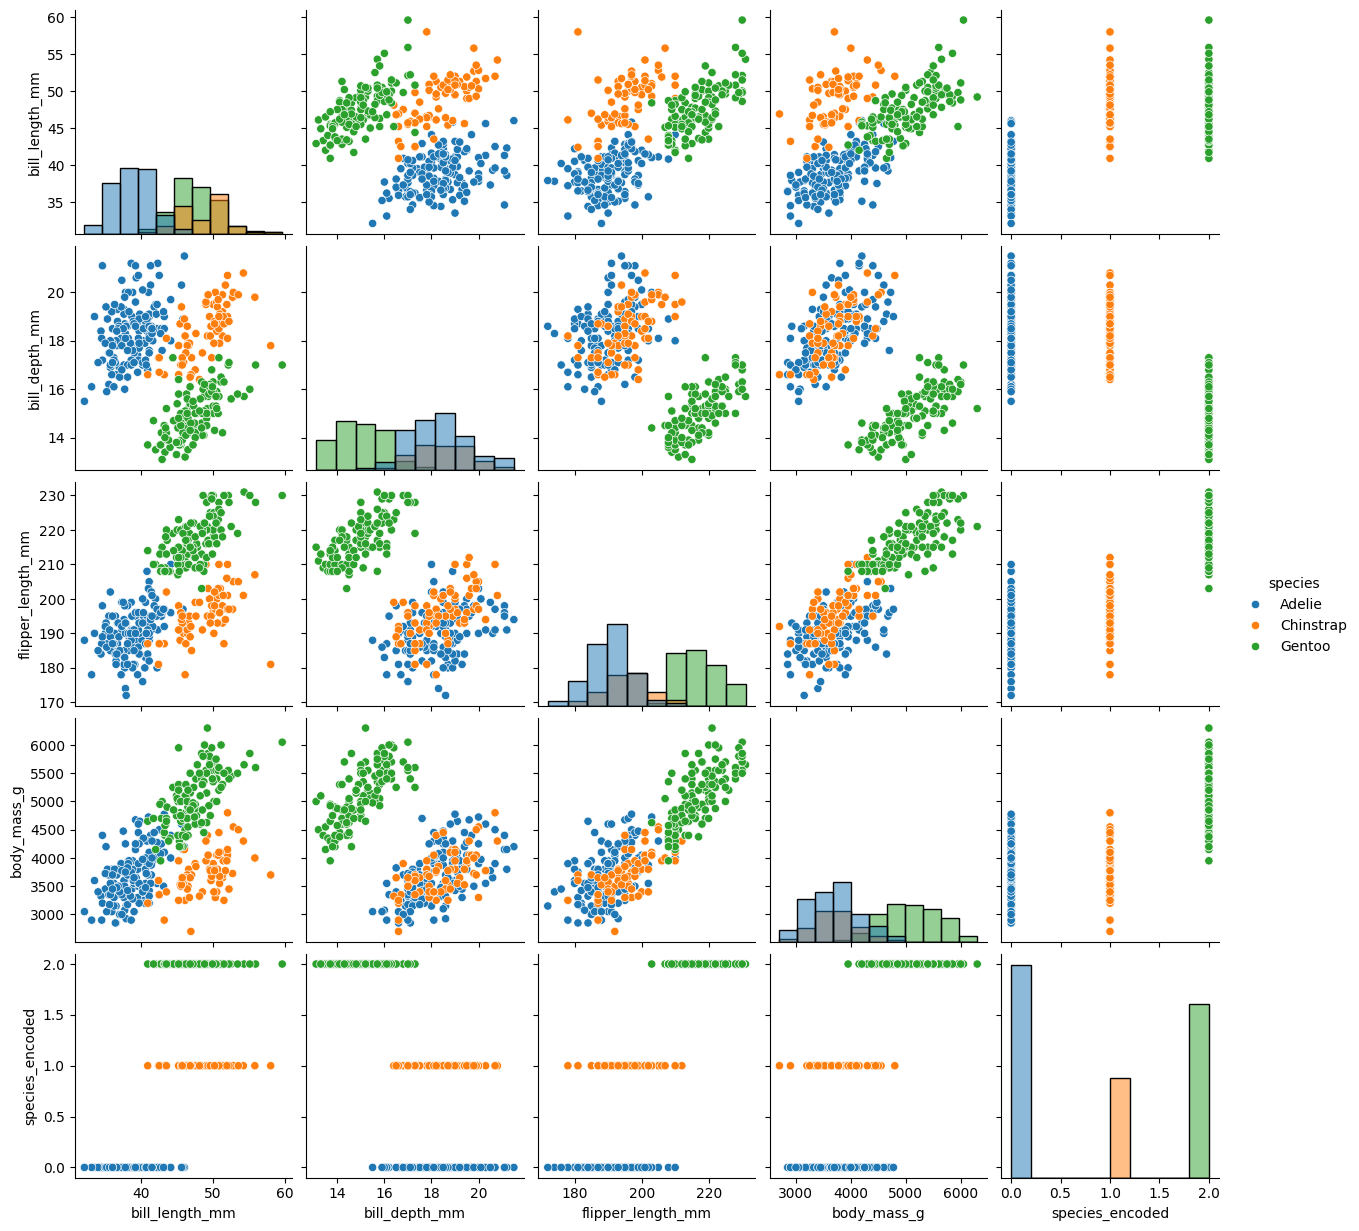

In [3]:
# Step 2: Encode target variable
le = LabelEncoder()
penguins = sns.load_dataset('penguins')

# Drop rows with missing values for simplicity
penguins = penguins.dropna()

# Encode species as numeric
penguins['species_encoded'] = le.fit_transform(penguins['species'])

# Features and target
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = penguins[features]
y = penguins['species_encoded']

#Visualize data with pairplot
sns.pairplot(penguins, hue='species', diag_kind='hist')
plt.show()



Question:

**Q1**: Do you observe overlap between species?

Gentoo iris flowers are well-separated, but Adelie and Chinstrap overlap in bill and flipper measurements, indicating that a non-linear SVM may perform better.

**Q2**:Which features seem most discriminative?

Flipper length and bill length seem most discriminative, as they clearly separate Gentoo from the other species in the pairplot.

### Step 3 — Split and Standardize

In [4]:

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train-test split done. Features standardized for SVM.")


Train-test split done. Features standardized for SVM.


### Step 4 — Train a Linear SVM

In [5]:

# Initialize linear SVM
linear_svm = SVC(kernel='linear', C=1.0, random_state=42, probability=True)

# Train the model
linear_svm.fit(X_train_scaled, y_train)

# Predict on test set
y_pred = linear_svm.predict(X_test_scaled)

# Evaluate performance
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy (Linear SVM): {acc:.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Test Accuracy (Linear SVM): 1.000

Confusion Matrix:
[[29  0  0]
 [ 0 14  0]
 [ 0  0 24]]

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67

